# TRABAJO SEMANAL 1: SÍNTESIS Y OPERACIONES DE SEÑALES
## ALUMNA: Maylen Monterde
### INTRODUCCIÓN:
En este trabajo se busca sintetizar distintos tipos de señales digitales, con el objetivo de estudiar sus características tanto en el dominio del tiempo como en el dominio de la frecuencia. Para todas las señales se utiliza una cantidad fija de muestras N=1000.
Se generan cinco señales con ciertas condiciones específicas de frecuencia, potencia media y de distribución estadística. Y luego, se implementa una señal 'bonus' y se verifica el Teorema de Parseval.
Para generar las señales pedidas se utilizaron las siguientes relaciones:
**Frecuencia de muestreo**: para asegurar al menos 10 muestras por período de una señal de frecuencia f $$f_s \geq 10 \cdot f$$
**Potencia media de una sinusoidal**: se utiliza la siguiente relación para hallar las distintas amplitudes $$P = \frac{A^2}{2}$$
**Potencia media de una señal cuadrada**: toma siempre el valor de su amplitud $$P = A^2$$
**Distribuciones de ruido**: se generaron dos tipos de ruido con la misma media y varianza, pero con distinta distribución de probabilidad.
- Distribución normal (Gaussiana): los valores se concentran cerca de la media y su dispersión está definida por el desvío estandar $$\sigma = \sqrt{\sigma^2}$$(parámetro que se utilizará en la función *np.random.normal*)
- Distribución uniforme: todos los valores dentro de un rango $[-a;a]$ son igual de probables sin concentración en el centro. Como la varianza se relaciona con sus límites mediante $$\sigma^2 = \frac{a^2}{3}$$ se despeja el valor de *a* para generar el ruido con la varianza pedida.

### CONSIGNA: 
Utilizando siempre N = 1000 muestras, se desea visualizar el módulo de la transformada de Fourier de las siguientes señales:
    
- Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.
- Misma señal con 2 W de potencia media y desfasada en π/2.
- Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.
- Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 
- Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50%

## RESOLUCIÓN:
Primero defino las librerias a utilizar y la función sinusoidal (creada las primeras clases de la materia).
La estructura de las 6 señales halladas es la misma: 
- Defino parámetros
- Creo la señal en el dominio del tiempo $[segundos]$
- Calculo su transformada de Fourier mediante *np.fft.fft*
- Paso al dominio de frecuencias
- Calculo el módulo de la señal
- Grafico fft vs frecuencia  

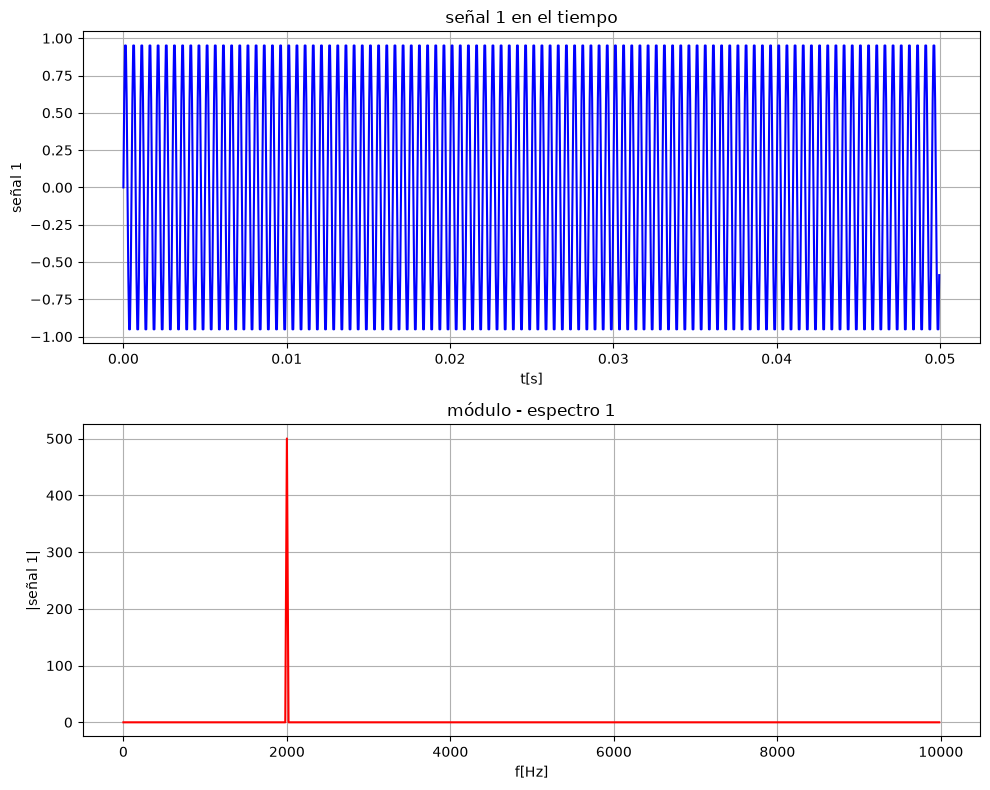

In [64]:
import numpy as np    
import matplotlib.pyplot as plt
from scipy import signal

#%% FUNCIÓN SENO:
def funcion_sen( A = 1, Vmed = 0, ff = 1, phi = 0, N = 1000, fs = 1000):
    tt = np.arange(N)/fs #arranca en 0 y termina en N-1 y eso se divide por la frecuencia de muestreo
    xx = A * np.sin( 2*np.pi*ff*tt + phi ) + Vmed
    return tt,xx

#%% ------ SEÑAL 1 ------
## PRÁMETROS:
N = 1000 # fijo para las 5 señales
ff1 = 2000 # dato
fs1 = 20000 # calculado con los 'al menos 10 puntos'
Amplitud1 = 1 # lo elijo yo
Vmed = 0
phi1 = 0

# creo la función en tiempo:
tt1, xx1 = funcion_sen(Amplitud1, Vmed, ff1, phi1, N, fs1)

# calculo su transformada de Fourier y paso a frecuencias (para poder graficar):
fft1 = np.fft.fft(xx1)
frecuencias1 = np.fft.fftfreq(N, 1/fs1)
frecpositiva1 = frecuencias1>=0 # nos quedamos con la mitad positiva (el resto es espejo, chequear)

# grafico la señal en el tiempo y el modulo de la FFT:
modulo1 = np.abs(fft1) # Módulo del FFT
plt.figure(1, figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(tt1,xx1,linestyle='-',color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal 1")
plt.grid(True) #me dibuja una grilla
plt.title("señal 1 en el tiempo")

plt.subplot(2,1,2)
plt.plot(frecuencias1[frecpositiva1],modulo1[frecpositiva1],label='señal 1',linestyle='-',color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal 1|")
plt.title("módulo - espectro 1")
plt.grid(True) #me dibuja una grilla
plt.tight_layout()

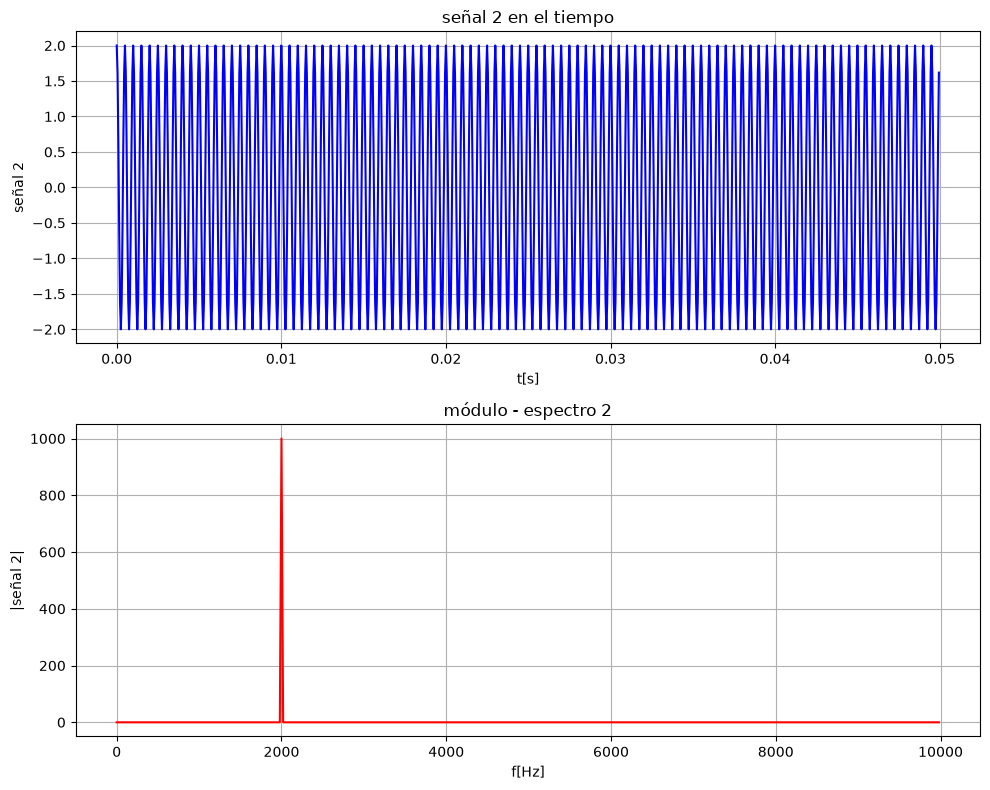

In [65]:
#%% ------ SEÑAL 2 ------
## PRÁMETROS (solo pongo los que cambian):
Pmedia2 = 2 #Watts
phi2 = np.pi/2
Amplitud2 = np.sqrt(2*Pmedia2)

# creo la función en tiempo:
tt2, xx2 = funcion_sen(Amplitud2, Vmed, ff1, phi2, N, fs1)

# calculo su transformada de Fourier:
fft2 = np.fft.fft(xx2)

# grafico la señal en el tiempo y el modulo de la FFT:
modulo2 = np.abs(fft2) # Módulo del FFT
plt.figure(2, figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(tt2,xx2,linestyle='-',color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal 2")
plt.grid(True) #me dibuja una grilla
plt.title("señal 2 en el tiempo")

plt.subplot(2,1,2)
plt.plot(frecuencias1[frecpositiva1],modulo2[frecpositiva1],label='señal 2',linestyle='-',color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal 2|")
plt.title("módulo - espectro 2")
plt.grid(True) #me dibuja una grilla
plt.tight_layout()

Tanto la señal 1 como la señal 2 son sinusoidales, las grafico juntas (en ambos dominios) para ver sus diferencias:

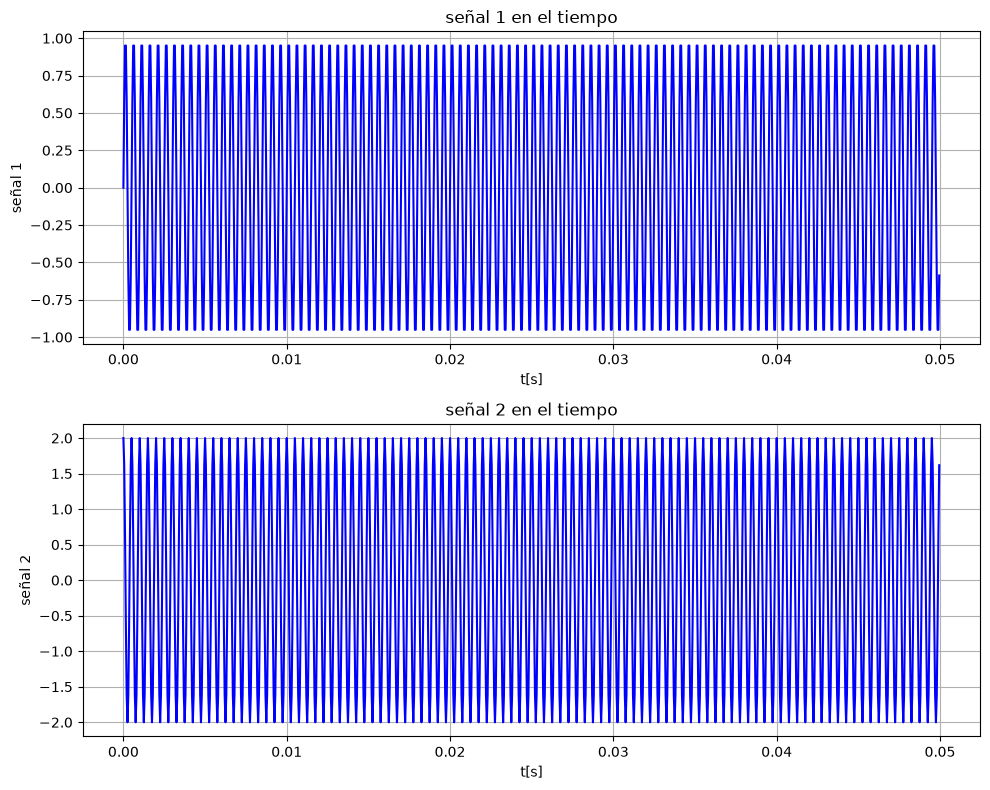

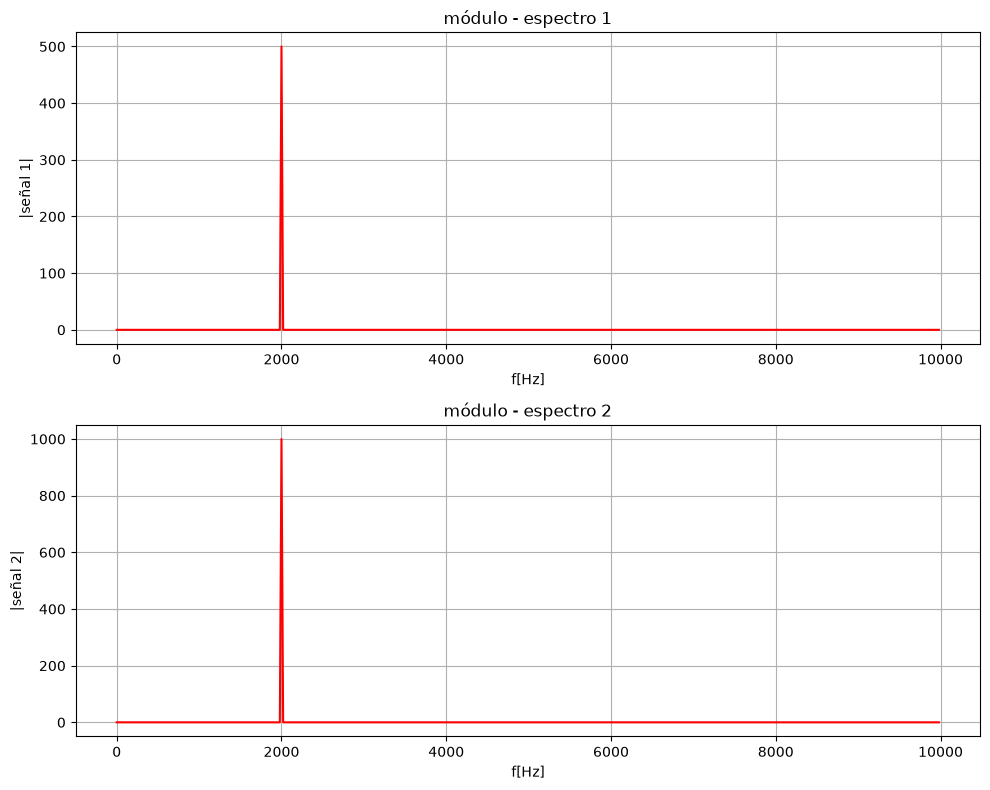

In [66]:
#señal 1 y 2 en el tiempo
plt.figure(3, figsize=(10, 8))
plt.subplot(2,1,1) 
plt.plot(tt1,xx1,linestyle='-',color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal 1")
plt.grid(True) #me dibuja una grilla
plt.title("señal 1 en el tiempo")

plt.subplot(2,1,2) 
plt.plot(tt2,xx2,linestyle='-',color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal 2")
plt.grid(True) #me dibuja una grilla
plt.title("señal 2 en el tiempo")
plt.tight_layout()

#señal 1 y 2 en frecuencia
plt.figure(4, figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(frecuencias1[frecpositiva1],modulo1[frecpositiva1],label='señal 1',linestyle='-',color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal 1|")
plt.title("módulo - espectro 1")
plt.grid(True) #me dibuja una grilla

plt.subplot(2,1,2)
plt.plot(frecuencias1[frecpositiva1],modulo2[frecpositiva1],label='señal 2',linestyle='-',color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal 2|")
plt.title("módulo - espectro 2")
plt.grid(True) #me dibuja una grilla
plt.tight_layout()

Comparando los gráficos de la señal 1 y  la señal 2 (donde solo varía la potencia media y el desfasaje), ambas sinusoidales presentaron un espectro con un único par de picos simétricos en $±2 k Hz$, sin energía en ninguna otra frecuencia, lo que es esperable para una señal compuesta por una sola componente frecuencial. La diferencia de potencia entre ambas se reflejó directamente en la altura del pico, a mayor potencia mayor amplitud, mientras que el desfasaje aplicado a la señal 2 no resultó visible en el módulo de la FFT, ya que esa información queda registrada en la fase del espectro y no en su magnitud.

Ahora genero y grafico las señales de ruido.

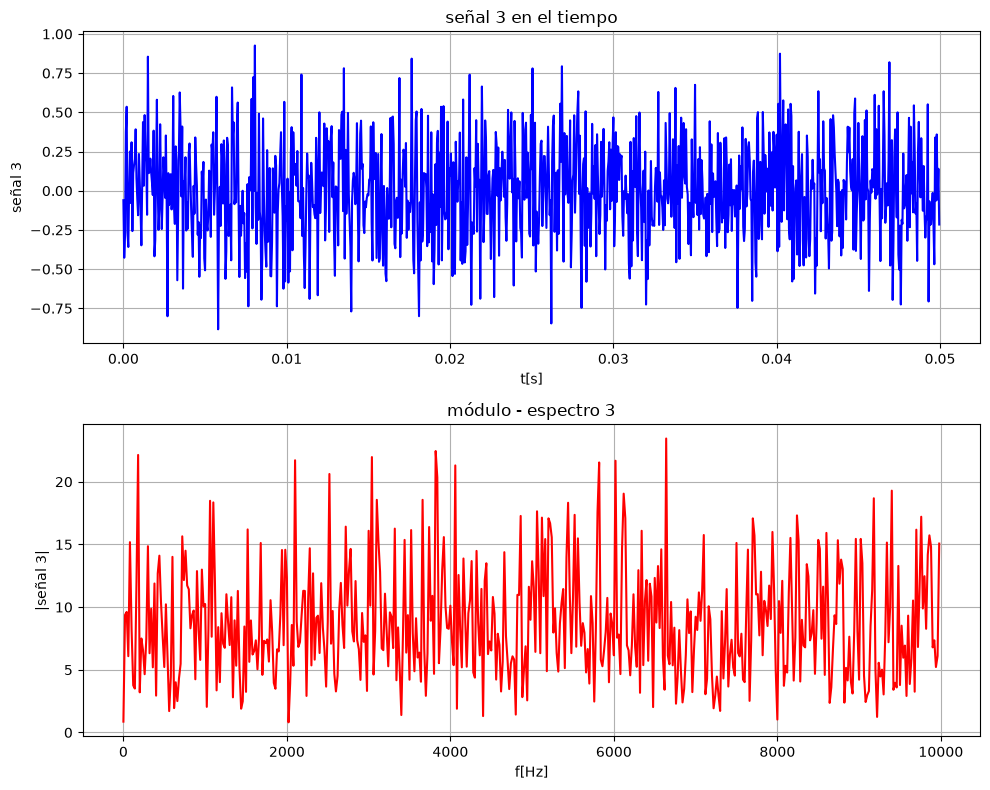

In [67]:
#%% ------ SEÑAL 3 ------
# Ruido con distribución normal (gaussiana)
Vmed_ruido = 0
varianza3 = 0.1
sigma3 = np.sqrt(varianza3)  # numpy pide desvío estándar, no varianza
xx3 = np.random.normal(Vmed_ruido, sigma3, N)

# calculo su transformada de Fourier:
fft3 = np.fft.fft(xx3)
modulo3 = np.abs(fft3)

# grafico la señal en el tiempo y el módulo de la FFT:
plt.figure(5, figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(tt1, xx3, linestyle='-', color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal 3")
plt.grid(True)
plt.title("señal 3 en el tiempo")

plt.subplot(2,1,2)
plt.plot(frecuencias1[frecpositiva1], modulo3[frecpositiva1], label='señal 3', linestyle='-', color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal 3|")
plt.title("módulo - espectro 3")
plt.grid(True)
plt.tight_layout()

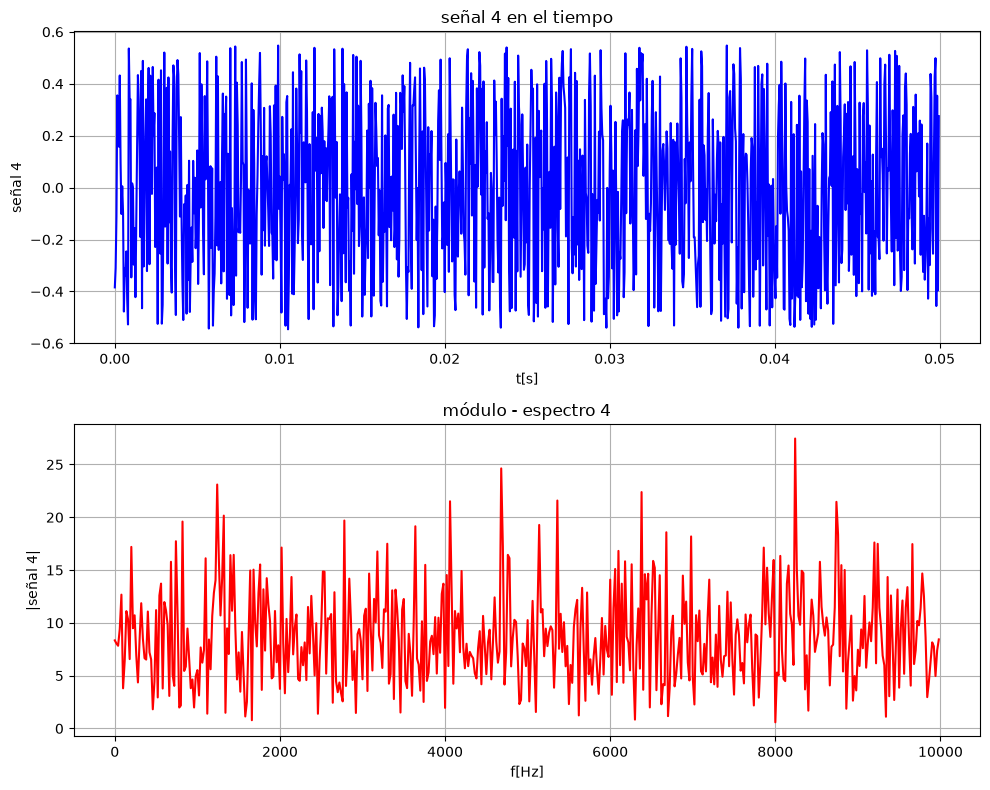

In [68]:
#%% ------ SEÑAL 4 ------
# Ruido con distribución uniforme
Vmed_ruido = 0
varianza4 = 0.1
# busco los intervalos de la uniforme:
a = np.sqrt(3*varianza4)

xx4 = np.random.uniform(-a,a,N)

# calculo su transformada de Fourier:
fft4 = np.fft.fft(xx4)
modulo4 = np.abs(fft4)

# grafico la señal en el tiempo y el módulo de la FFT:
plt.figure(6, figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(tt1, xx4, linestyle='-', color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal 4")
plt.grid(True)
plt.title("señal 4 en el tiempo")

plt.subplot(2,1,2)
plt.plot(frecuencias1[frecpositiva1], modulo4[frecpositiva1], label='señal 4', linestyle='-', color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal 4|")
plt.title("módulo - espectro 4")
plt.grid(True)
plt.tight_layout()

Grafico ambas señales de ruido para que se vean sus diferencias visualmente.

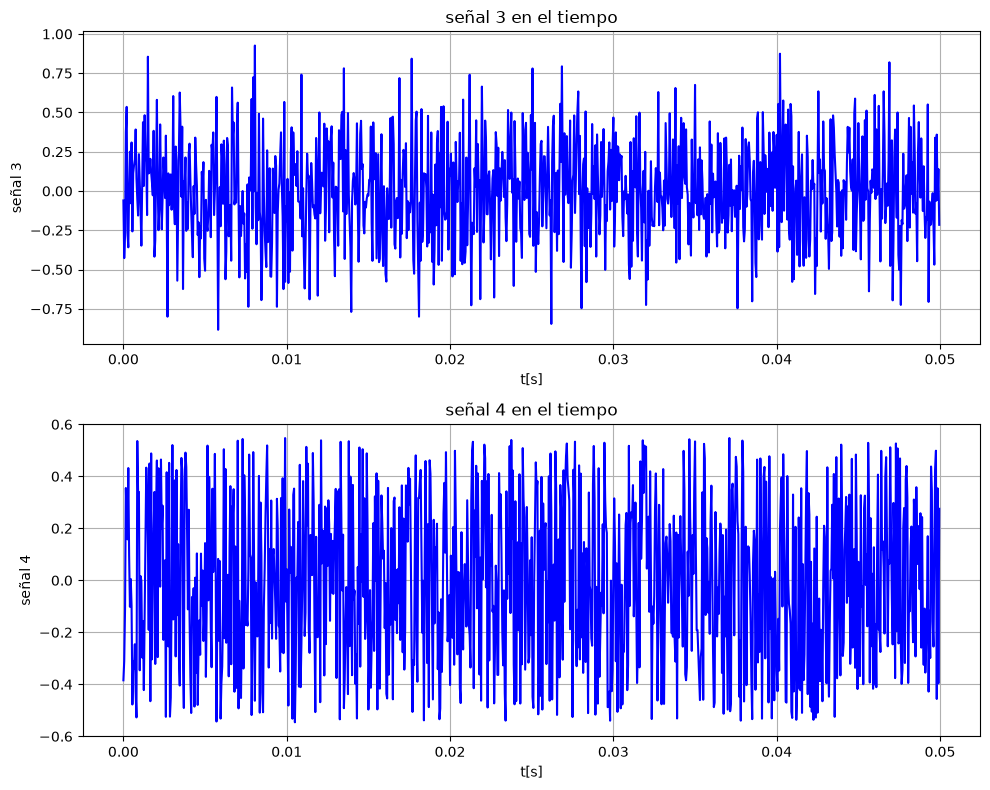

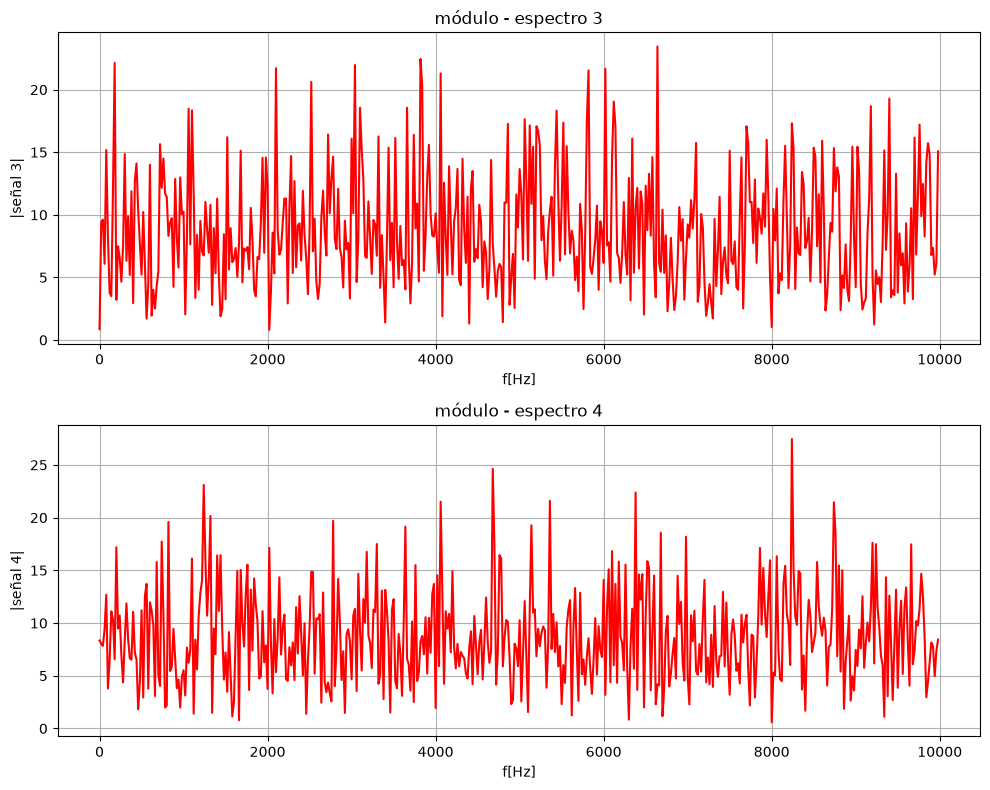

In [69]:
# señal 3 y 4 en el tiempo
plt.figure(7, figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(tt1, xx3, linestyle='-', color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal 3")
plt.grid(True)
plt.title("señal 3 en el tiempo")

plt.subplot(2,1,2)
plt.plot(tt1, xx4, linestyle='-', color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal 4")
plt.grid(True)
plt.title("señal 4 en el tiempo")
plt.tight_layout()

# señal 3 y 4 en frecuencia
plt.figure(8, figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(frecuencias1[frecpositiva1], modulo3[frecpositiva1], label='señal 3', linestyle='-', color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal 3|")
plt.title("módulo - espectro 3")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(frecuencias1[frecpositiva1], modulo4[frecpositiva1], label='señal 4', linestyle='-', color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal 4|")
plt.title("módulo - espectro 4")
plt.grid(True)
plt.tight_layout()

Comparando las señales 3 y 4 correspondientes al ruido, se observa claramente el tipo de distribución que tiene cada una en el dominio del tiempo. La señal 3 presenta valores concentrados mayoritariamente cerca de la media. Por otro lado, la señal 4 muestra una amplitud acotada de forma estricta dentro del rango calculado con los valores repartidos de manera más pareja dentro del intervalo, pero sin la concentración en el centro (como en el caso anterior).

Ahora calculo la señal pulso, utilizando la libreria scipy

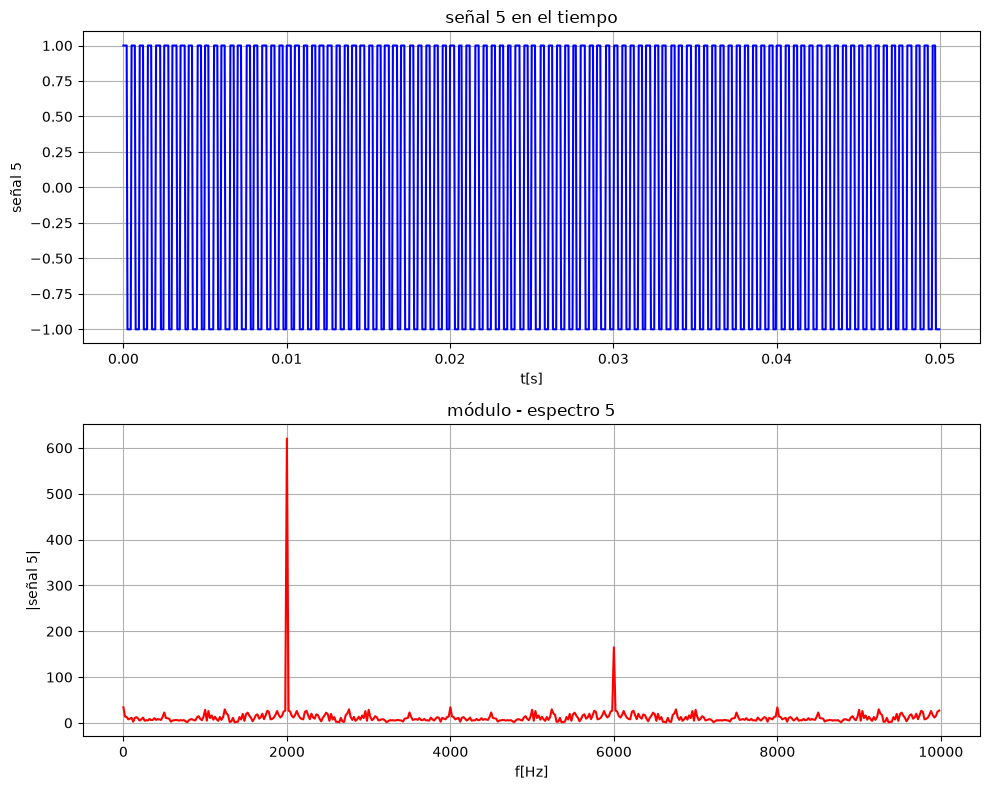

In [70]:
#%% ------ SEÑAL 5 ------
# Tengo que hacer una señal pulso 1W de potencia, misma frecuencia y ciclo de actividad 50%
# Parámetros:
ciclo_act = 0.5 
arg_fase = 2*np.pi*ff1*tt1 
Potencia = 1
Amplitud5 = np.sqrt(Potencia) # P = A² para la señal cuadrada

xx5 = Amplitud5 * signal.square(arg_fase, ciclo_act)

# calculo su transformada de Fourier:
fft5 = np.fft.fft(xx5)
modulo5 = np.abs(fft5)

# grafico la señal en el tiempo y el módulo de la FFT:
plt.figure(9, figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(tt1, xx5, linestyle='-', color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal 5")
plt.grid(True)
plt.title("señal 5 en el tiempo")

plt.subplot(2,1,2)
plt.plot(frecuencias1[frecpositiva1], modulo5[frecpositiva1], label='señal 5', linestyle='-', color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal 5|")
plt.title("módulo - espectro 5")
plt.grid(True)
plt.tight_layout()

En el dominio temporal se observa el gráfico esperado para una señal pulso rectangular. En cambio, en el dominio de la frecuencia se observan picos en $2000Hz$ y $6000Hz$ esto es debido a que la señal cuadrada tiene armónicos específicamente en las frecuencias impares de la frecuencia de la señal.

### SEÑAL BONUS:

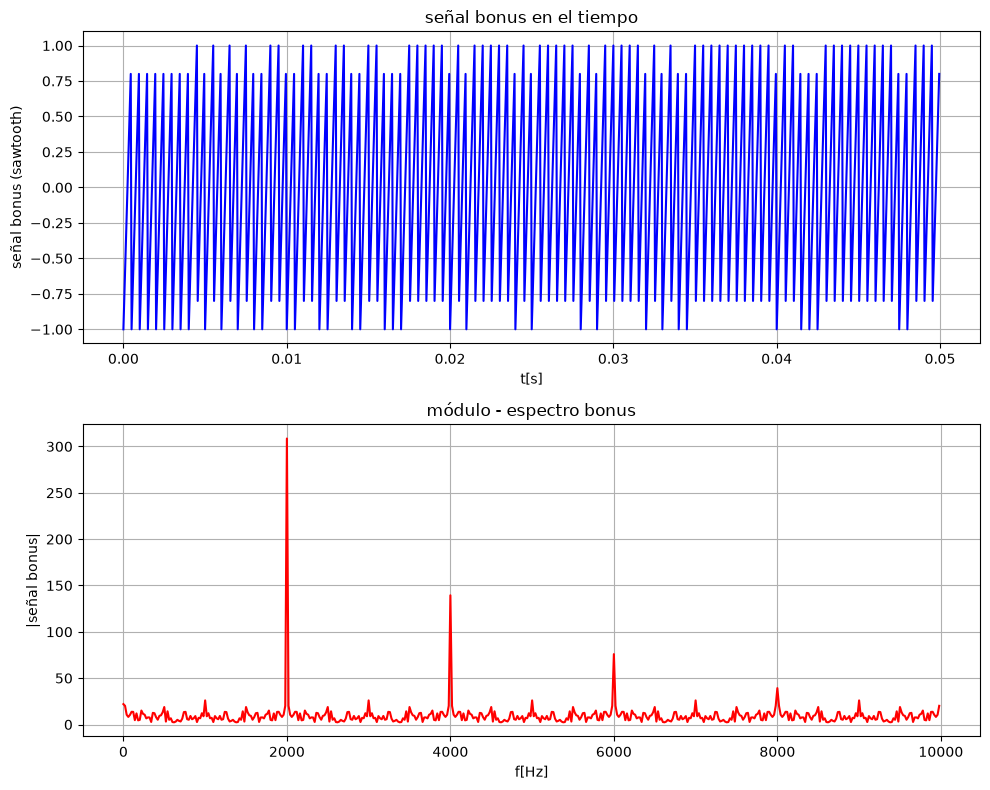

In [71]:
#%% --- SEÑAL BONUS ---
# Voy a usar sawtooth (diente de sierra)
ff6 = 2000  # misma frecuencia que las demás, por consistencia (no es un requisito)
Amplitud6 = 1

xx6 = Amplitud6 * signal.sawtooth(2*np.pi*ff6*tt1, width=1)
#controla en qué fracción del período ocurre la subida (vs la bajada). Con width=1 (default),
#sube durante el 100% del ciclo y cae instantáneamente al final — el diente de sierra "clásico". 
#Con width=0.5 sería simétrico (sube la mitad, baja la otra mitad, como un triángulo).

# calculo su transformada de Fourier:
fft6 = np.fft.fft(xx6)
modulo6 = np.abs(fft6)

# grafico la señal en el tiempo y el módulo de la FFT:
plt.figure(10, figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(tt1, xx6, linestyle='-', color='blue')
plt.xlabel("t[s]")
plt.ylabel("señal bonus (sawtooth)")
plt.grid(True)
plt.title("señal bonus en el tiempo")

plt.subplot(2,1,2)
plt.plot(frecuencias1[frecpositiva1], modulo6[frecpositiva1], label='señal bonus', linestyle='-', color='red')
plt.xlabel("f[Hz]")
plt.ylabel("|señal bonus|")
plt.title("módulo - espectro bonus")
plt.grid(True)
plt.tight_layout()

Para la señal bonus, se puede observar en el dominio del tiempo la 'rampa' característica del diente de sierra, subiendo de forma lineal en cada ciclo y cayendo abruptamente al final. 
En el dominio de la frecuencia y comparando con la señal 5 (pulso rectangular) que solo tomaba los armónicos impares, esta señal toma tanto armónicos impares como pares.

### TEOREMA DE PARSEVAL
IDEA: La energía (o potencia) de una señal es la misma tanto en el dominio del tiempo como en el de las frecuencias, es decir, solo cambia la forma de "mirarla". Entonces, si se suma el módulo al cuadrado de todos los valores de la fft y se divide por N², obtenes la potencia media. 
En el código que se observa a continuación, se utiliza la señal 1

In [72]:
#%% BONUS: PARSEVAL
# Potencia calculada en el tiempo:
potencia_tiempo = np.mean(xx1**2)

# Potencia calculada desde la FFT (Parseval):
potencia_frecuencia = np.sum(np.abs(fft1)**2) / N**2

print(f"Potencia en el tiempo: {potencia_tiempo}")
print(f"Potencia en frecuencia (Parseval): {potencia_frecuencia}")

Potencia en el tiempo: 0.5000000000000002
Potencia en frecuencia (Parseval): 0.5000000000000004


## CONCLUSIONES
A partir de las señales generadas se pudo observar cómo el contenido espectral (visualizado mediante el módulo de la FFT) depende directamente del origen y la forma de cada señal.
Las señales sinusoidales (1 y 2) presentaron un espectro concentrado en un único par de picos simétricos, correspondiente a su única componente frecuencial. En cambio, las señales con discontinuidades en su forma de onda (5 y bonus) mostraron múltiples picos ubicados en los armónicos de la frecuencia, ya que una forma de onda con cambios abruptos no puede representarse con una única frecuencia, sino que requiere la superposición de varias. Se observó además que la simetría particular de cada forma de onda determina qué armónicos aparecen: la señal cuadrada solo presentó armónicos impares, mientras que la señal bonus presentó tanto pares como impares.
Por otro lado, las señales de ruido (3 y 4) se diferencian ampliamente de las anteriores: al no poseer ninguna periodicidad, su energía se distribuyó de forma dispersa en todo el rango de frecuencias, sin picos definidos. Esto permitió comprobar que la distribución de probabilidad de un ruido (normal o uniforme) determina cómo se comportan sus valores en el dominio temporal, pero no necesariamente su contenido espectral, que depende más de su naturaleza aleatoria.
Finalmente, la verificación del Teorema de Parseval permitió confirmar que la potencia de una señal puede calcularse de forma equivalente tanto en el dominio del tiempo como en el de la frecuencia, reforzando la idea de que la FFT no agrega ni quita información: solo cambia la perspectiva desde la cual se analiza la señal.